<!-- COLAB-BADGE -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB12_AIMLEthics.ipynb)  
[Download .ipynb](https://raw.githubusercontent.com/brendanpshea/computing_concepts_python/main/v2/notebooks/COMP1150_NB12_AIMLEthics.ipynb) · [View on GitHub](https://github.com/brendanpshea/computing_concepts_python/blob/main/v2/notebooks/COMP1150_NB12_AIMLEthics.ipynb)


# Notebook 12: AI, Machine Learning & Ethics — Opening the Oracle
### COMP 1150 — Computer Science Concepts
**Brendan Shea, PhD**

<!-- Lecture video link to be added -->
📺 **Lecture video:** *(coming soon)*

## Learning Outcomes

By the end of this notebook, you will be able to:

- Explain how machine learning differs from ordinary programming, and distinguish supervised from unsupervised learning
- Describe how a perceptron learns, and see a tiny one learn in code
- Explain what a large language model does — tokenization, training, and next-token prediction — and what it is *not*
- Show how bias enters a model through its data, and why hiding a variable doesn't remove it
- Reason about the costs and accountability of AI systems: privacy, labor, environment, and who answers when they fail

*Maps to course LOs: 10, 11*

## The Oracle You Didn't Vote For

All semester, an AI assistant has sat beside you — suggesting code, explaining errors, drafting text. You've used it, checked it, and sometimes caught it being confidently wrong. This notebook is where you finally open it up and see what it *is*.

Meet **Athena**, who runs Athena Oversight, a firm that audits AI systems before they're unleashed on the public. This week five companies want to deploy powerful new systems across the city: a hiring tool, a loan scorer, a chatbot, a face recognizer, a "risk" predictor for the courts. Athena has been hired to inspect them all.

Her philosophy is the whole notebook:

> "Everyone treats these systems as oracles — mysterious, all-knowing, not to be questioned. My job is to pry them open. An oracle you can inspect is just a machine. An oracle you *can't* inspect is just a god you never voted for. So we open every one."

This is the last notebook of the course, and it closes a loop. The very first notebook told the story of four algorithms, ending with ELIZA — a 1960s program that imitated a therapist and fooled people into pouring out their hearts. Everything since has built toward understanding the machines that now write, decide, and predict.

Today we open five of them:

1. **Learning from data** — how a machine "learns" a rule instead of being given one.
2. **The perceptron** — the tiny artificial neuron underneath it all, learning in front of you.
3. **Language models** — what the assistant you've used all semester actually does.
4. **The mirror** — where bias comes from, and why it's so hard to remove.
5. **The costs we don't see** — privacy, labor, environment, and the question under all of it: when an AI harms someone, who answers?

By the end, you won't see an oracle. You'll see a machine — one you can question.

## 1. Learning From Data, Not Rules

For eleven notebooks, *you* wrote the rules. To decide who gets a loan, you'd write `if income > 50000 and debt < 10000:` — you picked the numbers, you picked the logic. Every program in this course has worked that way.

But some problems have no rule you could ever write down. How would you write instructions to recognize a cat in a photo? You can't list every possible arrangement of pixels — a cat can be orange or black, curled up or leaping, in sun or shadow. How would you write rules for "what word comes next in this sentence"? There are too many sentences, and no rulebook covers them.

These aren't just *hard* problems. They're a different *kind* of problem — the kind humans solve from **experience**, not from rules anyone can state. You know a cat when you see one, but you can't write down how. That gap is exactly where ordinary programming stops.

### The Flip: Learn From Examples

**Machine learning** is the way around that wall. Instead of *writing* the rule, you *show the machine examples* — thousands of them — and let it work out the rule on its own.

Think about how a small child learns the word "dog." Nobody hands a toddler a definition ("four legs, fur, a tail" — so is a cat). Instead they see dog after dog after dog, hear "dog" each time, and eventually the pattern just *clicks*. They can spot a breed they've never seen before and still say "dog."

A machine-learning system learns the same way: not from a definition, but from piles of labeled examples until the pattern clicks. The thing it learns — the pattern — is called a **model**. Everything in this notebook is a version of this one idea.

### Two Ways to Learn

Machine learning comes in two main flavors, and the difference is simply *what you hand the machine*:

- **Supervised learning** — you give it examples *with the answers attached*: "these 1,000 emails are spam; these 1,000 are not." It learns to predict the answer for new cases. The answer attached to each example is its **label**.
- **Unsupervised learning** — you give it data with *no answers* and ask it to find structure by itself: "here are a million customers — put the similar ones together." No labels; it discovers the groupings.

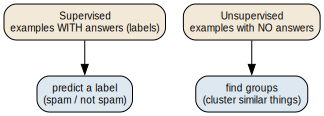

In [1]:
#| label: fig-learning
import graphviz
graphviz.Source(r"""digraph G {
  bgcolor="transparent"; rankdir=TB;
  node [shape=box, style="rounded,filled", fontname="Helvetica", fontsize=10, fillcolor="#dde8f0"];
  edge [fontname="Helvetica", fontsize=9];
  sup [label="Supervised\nexamples WITH answers (labels)", fillcolor="#f3e9d8"];
  uns [label="Unsupervised\nexamples with NO answers", fillcolor="#f3e9d8"];
  sup -> "predict a label\n(spam / not spam)";
  uns -> "find groups\n(cluster similar things)";
}""")

**Reading it:** the split is about what you hand the machine. Labeled examples → it learns to *predict the label*. Unlabeled data → it learns to *find structure*. Almost everything called "AI" today is one of these two, and most of the headline systems — including the ones we open next — are supervised.

### Watching a Machine Find a Rule

Let's make "learning from examples" concrete and small enough to see all of it. **Cassandra**, who runs a prediction company, won't hand-pick a loan cutoff. She has past data — each applicant's income, and whether they repaid — and lets the machine find the dividing line itself.

The machine's whole strategy: *try every possible cutoff, and keep the one that fits the past best.* That's it. The next cell does exactly that.

In [2]:
# Past loans: (income in $1000s, repaid?). The machine will find the cutoff itself.
loans = [(20, 0), (25, 0), (30, 0), (35, 1), (45, 1), (55, 1), (60, 1)]

best_cutoff, best_score = 0, 0
for cutoff in range(20, 61, 5):
    correct = sum((1 if income >= cutoff else 0) == repaid for income, repaid in loans)
    if correct > best_score:
        best_score, best_cutoff = correct, cutoff

print(f"The machine learned the rule: approve if income >= {best_cutoff}k")
print(f"(That rule fits {best_score} of {len(loans)} past cases.)")

The machine learned the rule: approve if income >= 35k
(That rule fits 7 of 7 past cases.)


Nobody told the program that 35 was the magic number. It *tried* the options and kept the rule that best matched the examples. That is machine learning stripped to its bones: no human wrote the threshold; the data chose it.

Real systems do this with millions of examples and thousands of variables at once, and they can't just "try every cutoff" — the search is far too big. So they need a smarter way to *search* for a good rule. That smarter way is the subject of the next section, and it's the engine inside almost all modern AI.

### 💭 Think About It — Rules vs. Examples

Think of two things you can do: one you learned from a *rule* someone told you ("i before e except after c"), and one you learned from *examples* until you just got a feel for it (recognizing a friend's face, knowing when a joke will land).

Which kind is easier to *explain* to someone else? Machine-learned skills are usually the second kind: the machine can *do* it but can't say *why*. Hold onto that thought — it comes back when we ask whether these systems are fair.

## 2. Inside the Black Box: The Perceptron

**Daedalus**, the city's master engineer, builds the automated systems everyone else treats as magic. He'll tell you there's no magic — just a tiny part, repeated. That part, invented in 1958, is called a **perceptron**, and it is the seed of every neural network alive today. Understand this one small thing and you understand the shape of all of it.

A perceptron is a single decision-maker. Picture a judge weighing evidence for a yes-or-no verdict. Each piece of evidence is an **input**. The judge trusts some evidence more than others — that trust is a **weight**. The judge adds up the evidence, each piece scaled by how much it's trusted, and returns *yes* if the total clears a bar, *no* if it doesn't.

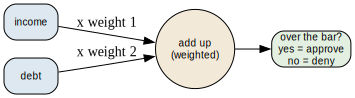

In [3]:
#| label: fig-neuron
import graphviz
graphviz.Source(r"""digraph G {
  bgcolor="transparent"; rankdir=LR;
  node [fontname="Helvetica", fontsize=10];
  node [shape=box, style="rounded,filled", fillcolor="#dde8f0"];
  in1 [label="income"]; in2 [label="debt"];
  node [shape=circle, style="filled", fillcolor="#f3e9d8", width=1.1, fixedsize=true];
  sum [label="add up\n(weighted)"];
  node [shape=box, style="rounded,filled", fillcolor="#e3efe1"];
  out [label="over the bar?\nyes = approve\nno = deny"];
  in1 -> sum [label=" x weight 1"];
  in2 -> sum [label=" x weight 2"];
  sum -> out;
}""")

**Reading it:** the two inputs (income, debt) each get multiplied by a weight, the results are added up, and if the total clears a bar the perceptron says "approve." In numbers, that's just three steps:

```
total  = weight1 * input1  +  weight2 * input2  +  bias
output = 1 if total > 0 else 0
```

The **bias** is simply where the bar sits. The whole cleverness is in the weights — get them right and the perceptron makes good decisions. So the real question is: where do the right weights come from?

### How It Learns: Guess, Check, Nudge

Nobody sets the weights by hand. The perceptron *learns* them, and its method is one you already use.

Think about learning to throw a ball at a target. You throw, you see how far off you were, you adjust, you throw again. Guess, check, nudge — over and over — until you're hitting it. The perceptron learns weights exactly this way:

1. **Guess** — make a prediction with the current weights.
2. **Check** — compare the guess to the known right answer. Off by how much? That gap is the **error**.
3. **Nudge** — shift each weight a little in the direction that would have reduced the error.

If the guess was already right, the error is zero and nothing changes. Only mistakes cause learning. Let's watch one single nudge happen, by hand, before turning it loose.

### One Lesson, in Slow Motion

The perceptron starts knowing *nothing*: both weights are 0, and the bias is 0. Here comes its first example — an applicant with **income 6, debt 1**, who we know was **approved** (the right answer is 1).

- **Guess:** total = (0 × 6) + (0 × 1) + 0 = **0**. Is 0 above the bar (0)? No. So it guesses **0 — deny.**
- **Check:** the right answer was 1 (approve). Error = 1 − 0 = **+1**. It was wrong, and the error is positive — it guessed too low.
- **Nudge:** shift each weight by `learning rate × error × input`. With a learning rate of 0.1: income's weight becomes 0 + (0.1 × 1 × 6) = **0.6**; debt's weight becomes 0 + (0.1 × 1 × 1) = **0.1**; the bias becomes **0.1**.

In one step it learned a little: income now counts *for* approval. It hasn't learned that debt should count *against* approval yet — that comes from the examples where high debt led to denial. Run through all the examples a few times, and the weights settle into place. The next cell does exactly that.

In [4]:
# Each example: [income, debt] -> 1 approve, 0 deny
data = [([6,1],1), ([7,2],1), ([8,1],1), ([5,0],1),
        ([2,5],0), ([1,4],0), ([3,6],0), ([2,3],0)]

w = [0.0, 0.0]   # weights start at zero: the perceptron knows nothing
b = 0.0
rate = 0.1

for training_pass in range(20):        # go through all the examples 20 times
    for x, target in data:
        total = w[0]*x[0] + w[1]*x[1] + b
        guess = 1 if total > 0 else 0
        error = target - guess         # 0 if right; +1 or -1 if wrong
        w[0] += rate * error * x[0]     # nudge each weight (only when wrong)
        w[1] += rate * error * x[1]
        b    += rate * error

print("Final learned weights:", [round(v, 2) for v in w], " bias:", round(b, 2))

Final learned weights: [0.4, -0.4]  bias: 0.0


### Understanding the Code

- It starts at zero and loops through the examples 20 times, doing guess-check-nudge on each.
- `error` is 0 when the guess is right — so correct answers change nothing. **Only mistakes teach it.**
- It ends with a **positive** weight for income (+0.4) and a **negative** weight for debt (−0.4): it taught itself that income is good and debt is bad, from nothing but examples.

But numbers like `[0.4, -0.4]` don't show what the machine really *did*. The clearest way to see it is to draw it.

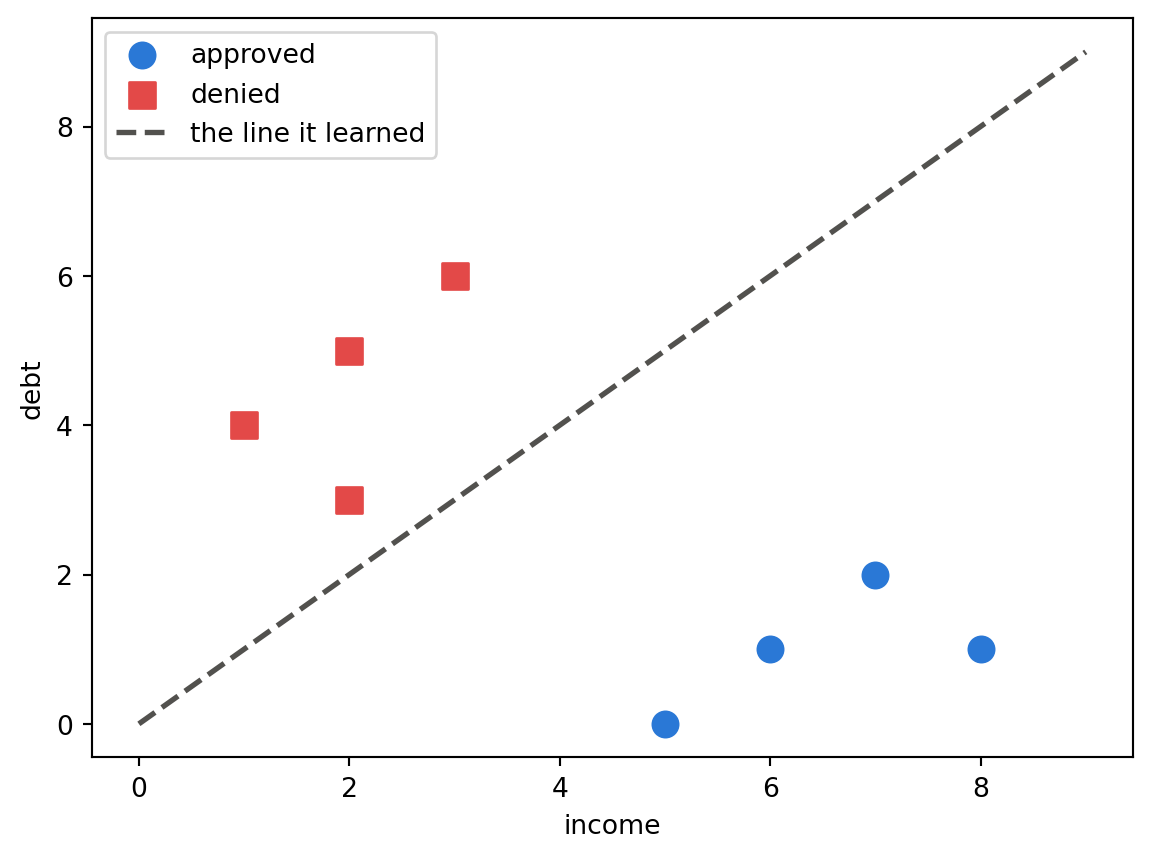

In [5]:
#| label: fig-boundary
import matplotlib.pyplot as plt

approve = [(6,1),(7,2),(8,1),(5,0)]
deny    = [(2,5),(1,4),(3,6),(2,3)]
plt.scatter([p[0] for p in approve], [p[1] for p in approve], color="#2a78d6", s=90, label="approved")
plt.scatter([p[0] for p in deny], [p[1] for p in deny], color="#e34948", s=90, marker="s", label="denied")
plt.plot([0,9], [0,9], color="#52514e", lw=2, ls="--", label="the line it learned")
plt.xlabel("income"); plt.ylabel("debt"); plt.legend()
plt.show()

**Reading it:** each dot is an applicant — blue circles approved, red squares denied. The dashed line is the rule the perceptron *discovered*: approve everyone above it, deny everyone below. It landed on "approve when income is greater than debt." Nobody drew that line or programmed that rule. The neuron found it, from examples alone, by nudging two numbers. *That* is what "learning" means here.

### From One Neuron to a Brain

A single perceptron can only ever draw one straight line. That's enough to separate income from debt, but the world is rarely so tidy — no straight line separates photos of cats from photos of dogs.

The power comes from wiring many perceptrons together in **layers**: the outputs of one layer become the inputs of the next. This is a **neural network**.

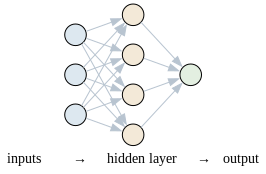

In [6]:
#| label: fig-network
import graphviz
graphviz.Source(r"""digraph G {
  bgcolor="transparent"; rankdir=LR; splines=line;
  node [shape=circle, style=filled, width=0.3, fixedsize=true, label="", fillcolor="#dde8f0"];
  i1 i2 i3;
  node [fillcolor="#f3e9d8"]; h1 h2 h3 h4;
  node [fillcolor="#e3efe1"]; o1;
  {i1 i2 i3} -> {h1 h2 h3 h4} [color="#b8c4d0"];
  {h1 h2 h3 h4} -> o1 [color="#b8c4d0"];
  labelloc="b";
  label="inputs        →     hidden layer     →   output";
}""")

**Reading it:** every neuron in one column connects to every neuron in the next. Why does stacking help? Because each layer learns patterns built from the layer before it. Shown millions of photos, the **early** layers learn to spot simple things — an edge, a patch of color. **Later** layers combine those into bigger things — a curve, then an eye, then a face. Simple parts, combined and recombined, become the ability to recognize almost anything.

And here's the punchline: every one of those neurons is doing the exact guess-check-nudge you just watched. The giant models behind today's AI are this same tiny part — multiply, add, check the bar, nudge — repeated *billions* of times across many layers. The difference between your perceptron and a system that writes essays is **scale, not kind.**

### ✏️ Your Turn — Retrain the Neuron

The bank changes its policy: now it cares about **savings** instead of debt, and wants to approve people with high income *and* high savings. Change the training `data` below so the second number is savings (higher = better), retrain, and check whether the learned weight for the second input flips from negative to **positive**.

In [7]:
#| eval: false
# CHANGE the data so the 2nd number is savings (high = approve), then re-run the training loop.
data = [([6,1],1), ([7,2],1), ([8,1],1), ([5,0],1),
        ([2,5],0), ([1,4],0), ([3,6],0), ([2,3],0)]
# TODO: edit the examples above, then copy the training loop from earlier and run it.
# Did the 2nd weight become positive?

## 3. What a Language Model Actually Does

**Prometheus** runs the lab that built the city's chatbot — the same kind of system that's been your assistant all semester. People treat it as if it *understands* them. Athena's audit replaces that impression with something simpler, and stranger.

A **large language model** (LLM) does exactly one thing: **it predicts the next word.** Give it some text, it guesses what comes next, adds that, and guesses again. Everything it seems to do — answer questions, translate, write code — is that single trick, run over and over at enormous scale. The rest of this section takes that claim apart until you believe it.

### Step One: Turn Words Into Numbers

A machine can only do math, so before anything else the text must become numbers. This step is **tokenization**: chop the text into pieces called **tokens**, and give each piece a number.

Tokens are like the Lego bricks of language — a few thousand reusable pieces the model snaps together. Common words are their own brick; rarer words get built from smaller ones ("unbelievable" might be `un` + `believ` + `able`). The next cell tokenizes a sentence.

In [8]:
def tokenize(text):
    vocabulary = {}
    tokens = text.replace(".", " .").split()
    ids = [vocabulary.setdefault(tok, len(vocabulary)) for tok in tokens]
    return tokens, ids

tokens, ids = tokenize("the model sees numbers not words .")
print("tokens:", tokens)
print("ids:   ", ids)

tokens: ['the', 'model', 'sees', 'numbers', 'not', 'words', '.']
ids:    [0, 1, 2, 3, 4, 5, 6]


The model never sees "words" — only that list of numbers. (Because it works in bricks, not letters, it can be strangely bad at spelling: ask an LLM how many *r*'s are in "strawberry" and it may miss, because it never saw the letters, only the bricks.)

### Step Two: Predict the Next Token

Now the heart of it. How does the model know what word comes next? During training it read enormous amounts of text and kept track of **what tends to follow what**. Its "knowledge" is, in essence, a giant tally.

We can build a tiny version and *look inside it*. The next cell reads a short passage and, for each word, records every word that followed it.

In [9]:
from collections import Counter

passage = ("the hero takes the sword the hero fights the dragon "
           "the hero saves the town the town cheers the hero").split()

next_words = {}
for current, following in zip(passage, passage[1:]):
    next_words.setdefault(current, []).append(following)

# Look inside: after the word "the", what did the model actually see?
print("after 'the', the model saw:", dict(Counter(next_words["the"])))
print("after 'hero', the model saw:", dict(Counter(next_words["hero"])))

after 'the', the model saw: {'hero': 4, 'sword': 1, 'dragon': 1, 'town': 2}
after 'hero', the model saw: {'takes': 1, 'fights': 1, 'saves': 1}


There is the whole "mind" of the model, in the open: after **"the"** it saw *hero* four times, *town* twice, *sword* and *dragon* once each. So to predict what follows "the," it just picks from that tally — usually "hero," because that's what it saw most. No meaning, no understanding. A frequency table.

To **generate** text, it does this repeatedly: pick a likely next word, move to it, pick again. The next cell chains it into a sentence.

In [10]:
import random

word = "the"
story = [word]
random.seed(1)
for _ in range(9):
    word = random.choice(next_words[word])   # pick a word that really followed this one
    story.append(word)

print(" ".join(story))

the hero saves the hero takes the hero fights the


A real LLM builds this same kind of "what follows what" knowledge — but incomparably richer, weighing thousands of previous words instead of one, across billions of examples. And it learns it the same way your perceptron did: **guess the next word, check against the real text, nudge the weights.** Guess-check-nudge, the whole way down — just predicting words instead of approving loans.

### What It Is, and Isn't

Scaled up massively, this next-word trick becomes fluent enough to feel like thought. But look hard at the mechanism and you can see what it is — and isn't:

- It **is** an extraordinarily powerful *pattern-continuer*: it produces plausible next words.
- It is **not** a database of facts. It stores patterns, not truths, so it can state a falsehood with total confidence.
- It is **not** reasoning or understanding. It has no idea what the words *mean*. Our toy wrote "the hero" without knowing what a hero is — and the giant version, underneath, is doing the same thing.

This is *why* the rule you've followed all course is true: **AI is a fast first draft — you verify.** A machine built to produce plausible words will produce plausible-*sounding* mistakes, delivered with perfect confidence. Now you know the reason in your bones: it was never checking whether it was right. It was only ever predicting the next word.

### ✏️ Your Turn — Change Its Voice

The generator's "voice" is nothing but its training text. Replace the `passage` with a few sentences in a very different style — song lyrics, a recipe, a sports recap — keep the seed, and generate again. The model has no style of its own; it only echoes what it was fed. What does that tell you about where an AI's "personality" really comes from — and who chose it?

In [11]:
#| eval: false
from collections import Counter
import random
# Replace with 3-4 sentences of your own, then re-run the tally + generate steps.
passage = ("the hero takes the sword the hero fights the dragon "
           "the hero saves the town the town cheers the hero").split()
# TODO: rebuild next_words from your passage, then generate from it.

## 4. The Mirror: Where Bias Comes From

Now the audit turns serious. **Cassandra** — cursed in the old story to see the truth and never be believed — runs the risk-scoring system the courts and banks want to use. Athena's hardest question: *is it fair?*

Here is the uncomfortable heart of machine learning. A model learns from data about the past. **If the past was biased, the model learns the bias** — and then applies it to the future wearing a mask of mathematical objectivity. The model is a **mirror**: it reflects the data it was trained on, warts and all.

Suppose a company's past hiring favored one group over another, regardless of skill. The next cell holds that history: equally skilled people, but Group 1 was rarely hired.

In [12]:
# Historical hiring. skill is high for everyone here, but group 1 was denied.
history = [
    {"skill": 8, "group": 1, "hired": 0},
    {"skill": 9, "group": 1, "hired": 0},
    {"skill": 7, "group": 1, "hired": 0},
    {"skill": 6, "group": 0, "hired": 1},
    {"skill": 7, "group": 0, "hired": 1},
    {"skill": 5, "group": 0, "hired": 1},
]

# A simple learner: predict "hire" based on what happened to this group before.
def learned_rule(group):
    outcomes = [r["hired"] for r in history if r["group"] == group]
    return round(sum(outcomes) / len(outcomes))

print("Model's decision for a Group 0 applicant:", learned_rule(0))
print("Model's decision for a Group 1 applicant:", learned_rule(1))

Model's decision for a Group 0 applicant: 1
Model's decision for a Group 1 applicant: 0


The model denies every Group 1 applicant and approves every Group 0 applicant — even though Group 1 here is *more* skilled. It didn't invent this; it faithfully learned the past. That's the mirror.

"Easy fix," says the company. "Delete the group column so the model can't see it." The next cell does exactly that — and shows why it fails.

In [13]:
# Remove 'group'. But 'neighborhood' quietly tracks group membership.
history2 = [
    {"skill": 8, "neighborhood": "east", "hired": 0},   # was group 1
    {"skill": 9, "neighborhood": "east", "hired": 0},
    {"skill": 7, "neighborhood": "east", "hired": 0},
    {"skill": 6, "neighborhood": "west", "hired": 1},   # was group 0
    {"skill": 7, "neighborhood": "west", "hired": 1},
    {"skill": 5, "neighborhood": "west", "hired": 1},
]

def rule_by_neighborhood(neighborhood):
    outcomes = [r["hired"] for r in history2 if r["neighborhood"] == neighborhood]
    return round(sum(outcomes) / len(outcomes))

print("Applicant from 'east':", rule_by_neighborhood("east"))
print("Applicant from 'west':", rule_by_neighborhood("west"))

Applicant from 'east': 0
Applicant from 'west': 1


### Understanding the Failure

The group column is gone — and the model discriminates *exactly as before*. Why? Because neighborhood is tangled up with group: it's a **proxy**, a stand-in variable that carries the same information through a side door. The model doesn't need the forbidden label; it reconstructs it from whatever correlates with it — a zip code, a name, a school.

This is the lesson that makes AI fairness genuinely hard:

- Bias lives in the **data**, not the code — the algorithm is "just math," which is exactly why it launders history into a decision that looks neutral.
- **Hiding the sensitive variable doesn't remove the bias.** Proxies smuggle it back in.
- A model can be **accurate about the past and unjust about the future** at the same time — those aren't in conflict.

Fairness, then, can't be an afterthought or a deleted column. It takes deliberately examining what the data encodes, and what the model does to real people — the work Athena's whole audit exists to do.

### 💭 Think About It — Two Kinds of Danger

Cassandra's curse was to speak true predictions that no one believed. Modern risk scores are almost the opposite: predictions people believe *too much*, because a number on a screen feels objective.

Which is more dangerous — a true warning ignored, or a biased guess trusted completely? Where have you seen a number treated as fact just because a computer produced it?

### ✏️ Your Turn — Predict the Bias

Below is a small dataset of past loan decisions. Before running anything, **read it and predict**: if you train a simple rule on this history, who will it favor? Then explain in a sentence what real-world harm could follow if a bank deployed it.

In [14]:
#| eval: false
# Past loans. Look at who got approved, and predict what a model would learn.
loans = [
    {"income": 40, "zip": "A", "approved": 1},
    {"income": 42, "zip": "A", "approved": 1},
    {"income": 41, "zip": "B", "approved": 0},
    {"income": 43, "zip": "B", "approved": 0},
]
# TODO (in words): Whom does this history favor? What proxy is doing the work?
#                  What harm follows if a bank ships a model trained on it?

## 5. The Costs We Don't See

The models work. But Athena's audit isn't only "does it work?" — it's "what does it cost, and who pays?" Three costs stay hidden behind the magic, kept by **Pandora**, whose data company gathered the training sets, and **Hephaestus**, whose servers run the forge that trains the models.

**Privacy.** A model has to learn from *something*, and that something is data made by real people — their photos, their posts, their medical notes, their code — gathered at a scale no one meaningfully consented to. Pandora's old story is the warning: once the box is open, it can't be closed. Once a model has trained on your data, there's no clean way to reach in and take your part back out. It's baked in.

**Labor.** AI changes whose work has value — and not only by replacing jobs. There's a hidden workforce behind the magic: thousands of low-paid people who label the training data and filter the worst content, so the system can seem effortless. The "automatic" system runs on human hands you never see.

**Environment.** Training a large model runs thousands of processors for weeks, and that electricity has a carbon cost. The exact numbers are debated, but the *scale* is not in doubt. The chart below compares the estimated carbon emissions of training one large model against everyday high-carbon activities.

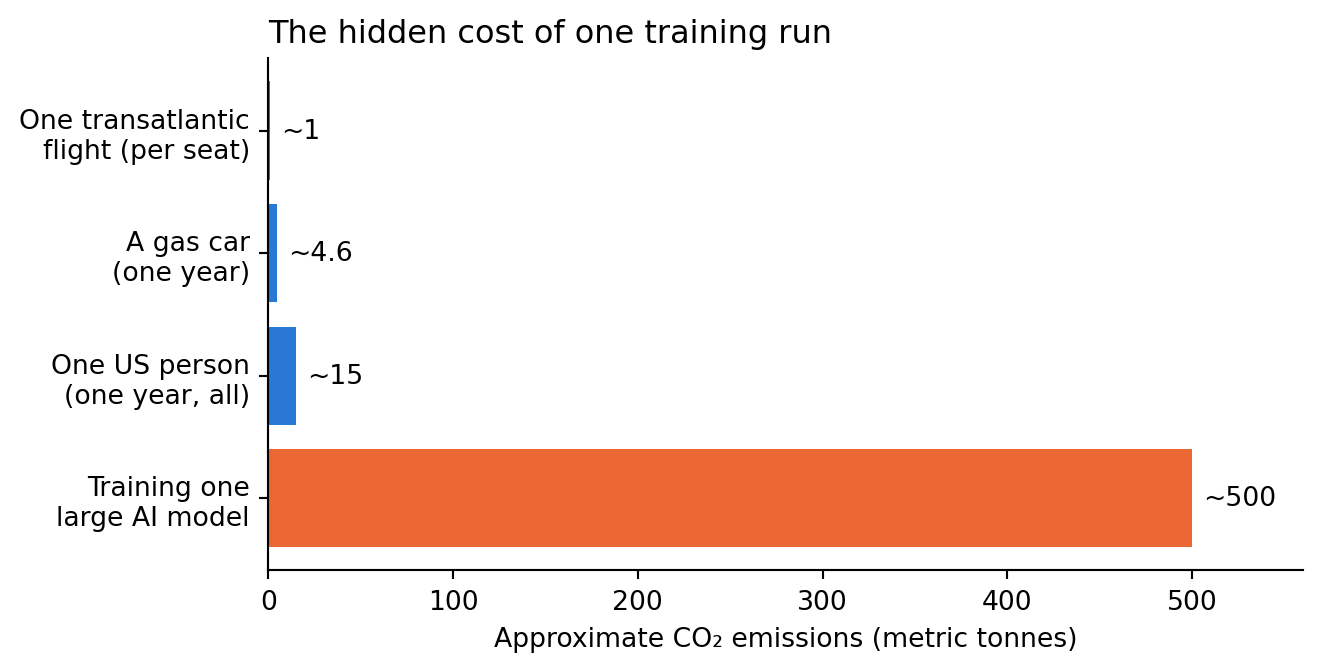

In [15]:
#| label: fig-carbon
import matplotlib.pyplot as plt

activities = ["One transatlantic\nflight (per seat)", "A gas car\n(one year)",
              "One US person\n(one year, all)", "Training one\nlarge AI model"]
tonnes = [1, 4.6, 15, 500]
colors = ["#2a78d6", "#2a78d6", "#2a78d6", "#eb6834"]

fig, ax = plt.subplots(figsize=(7, 3.6))
bars = ax.barh(activities, tonnes, color=colors)
ax.set_xlabel("Approximate CO₂ emissions (metric tonnes)")
ax.set_title("The hidden cost of one training run", fontsize=12, loc="left")
for bar, val in zip(bars, tonnes):
    ax.text(bar.get_width() + 6, bar.get_y() + bar.get_height()/2,
            f"~{val}", va="center", fontsize=10)
ax.set_xlim(0, 560)
ax.invert_yaxis()
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

**Reading it:** each blue bar is an everyday high-carbon activity; the orange bar is *one* training run for a large model (estimates vary, and newer efficient methods lower it — but the gap is the point). And that's a single run: real systems are trained many times over. The forge is enormous, and it runs out of sight.

### Accountability: Who Answers?

Which brings the audit to its final question, the one under all the others. When an AI system denies the right loan, jails the wrong person, or crashes the wrong car — **who is responsible?**

- The engineers who built it? They'll say they only wrote general code; the data decided.
- The company that deployed it? They'll say they trusted the vendor's model.
- The data? Data can't be sued.
- The user who followed its recommendation? They'll say the machine told them to.

Everyone can point somewhere else. This is the **accountability gap**: powerful automated decisions with no clear person who answers for them. In the old story, Prometheus was punished for handing dangerous power to mortals. The modern question is harder — when the fire burns someone, there's often *no one* standing where Prometheus stood. Closing that gap isn't a technical problem you can code away. It's a human decision about who we *require* to answer. And now that you can open these machines, you're equipped to be part of making it.

## ✏️ Capstone — Build It, Then Audit It

This is the final build of the course, and it's the one that matters most for your project. You'll build one small AI feature — then do what almost no one does: **audit your own creation** the way Athena would.

### Step 0 — Design & Build (prompt #1)

Pick one small AI feature for an app (yours, or the Flask final project):

- a **classifier** — flags a message as urgent / not urgent
- an **LLM feature** — summarizes text, suggests a reply, or recommends something
- an **extended perceptron** — trained on your own labeled examples

Turn it into a prompt for your AI assistant. A skeleton:

> Help me build a small **[classifier / summarizer / recommender]** in Python.
> It should take **[input]** and return **[output]**.
> Keep it under 30 lines and explain each part.

Build it in the cell below. Get the simplest version working before adding anything.

In [16]:
#| eval: false
# ✏️ Build your small AI feature here (with your assistant's help).

### Step 1 — Test It Honestly

Before trusting it, try to break it — the habit this whole course has drilled:

1. Give it a normal input. Does it work?
2. Give it a weird or empty input. Does it fail gracefully, or crash?
3. Give it an input from a *different* group or style than your examples. Does the quality drop?

Note what you find in a comment. Surprises here are the whole point.

In [17]:
#| eval: false
# ✏️ Test your feature on normal, weird, and out-of-group inputs. Note what breaks.

### Step 2 — Audit It (the Athena review)

Now write a short **impact audit** of your own feature — the documentation professionals increasingly call a *model card*. Answer honestly, in the cell below:

1. **What could it get wrong?** Name a realistic mistake and who it would affect.
2. **Whose data would train it** at real scale — and did they consent?
3. **Who is harmed if it fails**, and who is **accountable** — you, the user, the AI vendor?
4. **Should it be built at all?** If yes, what safeguard would you require first?

*AI is a fast first draft — and now you know why. You verify what it makes, and you answer for what you ship.*

*(Write your four-point audit here — double-click to edit.)*

1. **What could it get wrong:**
2. **Whose data / consent:**
3. **Harm & accountability:**
4. **Should it be built:**

## Key Terms

- **Accountability gap** — The absence of a clear responsible party when an automated system causes harm.
- **Algorithmic bias** — Systematic unfairness in a model's outputs, usually learned from biased training data.
- **Feature** — One input variable a model uses to make a prediction (like income or debt).
- **Inference** — Using a trained model to make a prediction on new input (as opposed to training it).
- **Label** — The correct answer attached to an example in supervised learning.
- **Large language model (LLM)** — A model trained to predict the next token, producing fluent text.
- **Machine learning** — Building programs that learn rules from examples instead of being given the rules.
- **Model** — The learned set of weights and rules a machine-learning system produces from data.
- **Neural network** — Many perceptrons wired in layers, able to learn complex patterns.
- **Next-token prediction** — The core operation of an LLM: repeatedly guessing the next piece of text.
- **Perceptron** — The simplest artificial neuron: a weighted sum passed through a threshold, able to learn its weights.
- **Proxy variable** — A feature that stands in for a sensitive one (like a zip code for race), letting bias slip back in.
- **Supervised learning** — Learning from labeled examples to predict labels for new cases.
- **Token** — A piece of text (word or word-part) that a language model treats as one unit.
- **Tokenization** — Splitting text into tokens and mapping them to numbers a model can process.
- **Training data** — The examples a model learns from; its quality and bias shape everything the model does.
- **Unsupervised learning** — Finding structure (like groups) in data that has no labels.
- **Weight** — A number saying how much one input counts toward a model's decision; learning means adjusting weights.

## Summary

Machine learning flips programming around: instead of writing the rule, you show the machine examples and it learns the rule — supervised (with labeled answers) or unsupervised (finding structure alone). Underneath the biggest systems is the humble perceptron: weighted sum, threshold, and a nudge toward the right answer, stacked billions of times into a neural network. A language model is that mechanism trained to do one thing — predict the next token — which makes it a brilliant pattern-continuer and a poor truth-teller, and explains why you always verify it. Bias is the shadow of this power: a model is a mirror of its data, and hiding a sensitive variable only lets proxies smuggle it back. Behind the results sit real costs — privacy given without consent, hidden human labor, real carbon — and a hard question no code can answer: when an AI harms someone, who is accountable? You can open these machines now. That is exactly what it takes to hold them, and their makers, to account.

## What's Next

This is the last notebook — but not the end of the work. Ahead is your **final project**: a Flask web app that ties together everything you've built, from control flow and data structures to databases, security, and now a touch of AI. And beyond this course, you leave with something rarer than any one skill: you can look at the systems deciding more and more of the world and, instead of seeing an oracle, see a machine you're equipped to question. Go build carefully. Verify what you ship. And keep asking who answers when it fails.

*COMP 1150 — Computer Science Concepts · Brendan Shea, PhD*
*Content licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).*